In [1]:
import numpy as np
import scipy as scipy
import scipy.special
import matplotlib.pyplot as plt
from matplotlib import colors
import time
import uncertainties as error
import pandas as pd
np.random.seed(314159) #pi seed for pi finding

# Problem 1a.)

There are 52 cards in the deck. The probability of drawing a Heart or a King involves you drawing one of these cards out of the 52.

Ace of Hearts
Two of Hearts
Three of Hearts
Four of Hearts
Five of Hearts
Six of Hearts
Seven of Hearts
Eight of Hearts 
Nine of Hearts
Ten of Hearts
Jack of Hearts
Queen of Hearts
King of Hearts
King of Spades
King of Diamonds
King of Clubs

This is 13+4-1. The minus 1 is because we double count the King of Hearts if we just add the number of Kings and the number of Hearts. 

This is 16 possible cards out of 52. Therefore we can say

P(Hearts or King|Deck)=16/52

# Problem 1b.)

If we consider the probabilities of drawing a King and drawing a Heart seperately, we find that

P(Heart|Deck) = 13/52

P(King|Deck) = 4/52

For independent probabilities, we should be able to take P(Heart|Deck)P(King|Deck) = P(Heart AND King|Deck)

13/52 times 4/52 = 52/52^2 or 1/52. In this case this represents drawing a card which is both a king and a heart, which would be the King of Hearts. The probabilities are independent. 

Another way of thinking about this is if you are told I have a King, you do not gain any information about what suit my card is, and vice versa if I have a card and tell you it is a Heart you gain no information on if my card is a King.

The independence is not the overlap(as I naively thought at first), the probability of drawing a king OR heart is 16/52 due to overlap but these are still independent variables.

# Problem 1c.)

If we add a single Joker to the deck, we add a new card which is neither a King nor a Heart. 

P(Heart|Deck+Joker) = 13/53

P(King|Deck+Joker) = 4/53

We have P(Heart OR King|Deck+Joker) = 16/53 as we avoid double counting the King of Hearts.

For testing independence, we again have P(A AND B)=P(A)P(B) for independent variables. 

P(King AND Heart) = 1/53 as we only have the King of Hearts

P(King)P(Heart) = 4(13)/53^2 = 52/53^2

We see these probabilities are NOT equal, as P(King AND Heart)=53/53^2 whereas P(King)P(Heart)=52/53^2

A way of thinking of this is if I draw a card, and tell you it is a Heart, you now can eliminate all 40 cards instead of 39. Because the Joker can never be a Heart OR a king, me telling you the state of the card eliminates completely the possibility of me having the Joker, whereas it does not eliminate the possibility of me having any other value. The Joker has the unique property that it can be eliminated completely from a single piece of information while any other card needs both the suit and the value.

==========================================================================================================

# Problem 2a.)

In [3]:
#Some notes to myself
#We drop pencils at random and see if they cross board lines. Board lines are spaced every D, pencil is l long
#Angle is random
#We can simplify the math by saying a pencil always falls -d/2<x<d/2 to the nearest board. And we only care about the nearest
#actually if this is just to the nearest, 0<x<d/2 should work
#The pencil falls at random angle, I'll define the angle as 0 if pencil is parallel to board lines
#Therefore the pencil covers a distance (l/2)sin(theta) to the boardline

#ooo I bet I can make a graph where x and y are angle and distance, and then color in if it crosses a boardline

In [4]:
#ope let's also derive the actual probability
#P(theta)=Uniform(0, pi/2) since we always measure the acute(less than pi/2) angle to the board lines
#P(x)=Uniform(0, D/2) since distance is always positive and measured towards nearest board
#Since P(theta) and P(x) are independent, P(theta, x) = P(theta)P(x)

#For uniform distributions we need to keep them normalized. 
#P(theta)=2/pi Uniform(0, pi/2)
#P(x)=2/D Uniform(0, D/2)
#P(x, theta) = 4/(piD)

#We cross a line if x is less than or equal to l/2 sin(theta)
#To find the total probability, we marginalize over all the possible values. Integrate
#P = integral from 0 to pi/2 integral from 0 to l/2sin(theta) 4/(piD) dx dtheta
#P = 4/(piD) integral from 0 to pi/2 integral from 0 to l/2sin(theta) dx dtheta
#P = 4/(piD) integral from 0 to pi/2 l/2 sin(theta) dtheta
#P = 2l/(piD) integral from 0 to pi/2 sin(theta) dtheta
#P = 2l/(piD) (-cos(theta) evaluated at pi/2 and 0)
#P = 2l/piD (-(-1)-(0))
#P = 2l/piD

#and for later we rearrange and find pi=2l/PD

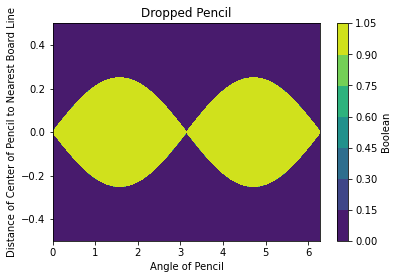

In [5]:
densityAngle=1000
densityDistance=1000
D=1
L=0.5

AnglePrior=np.linspace(0, 2*np.pi, densityAngle) #angle is always between 0 and 2pi
DistancePrior=np.linspace(-D/2, D/2, densityDistance)

#I'm going to make a meshgrid and compute what the length of the pencil towards the boardline is
xx, yy = np.meshgrid(DistancePrior, AnglePrior)
zz = np.abs((L/2)*np.sin(yy)) > np.abs(xx)
plt.contourf(yy, xx, zz)
# plt.axis('scaled')
plt.colorbar(label = 'Boolean')
plt.title('Dropped Pencil')
plt.ylabel('Distance of Center of Pencil to Nearest Board Line')
plt.xlabel('Angle of Pencil')
plt.show()

#Oops this isn't really monte carlo. Lemme make a random one instead of a grid one

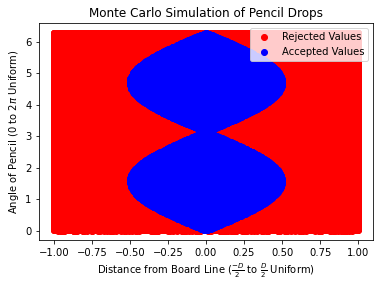

In [6]:
#oop should probably have an actual Monte Carlo sim for this by selecting random points rather than this meshgrid
D=2
L=1
def Uniform(start, stop):
    return((np.random.random()*(stop-start) + start)) #select a random number from 0, 1 and move it to start, stop

loopLimit=100000
#Accept-Reject Method

AcceptedValues=[]
RejectedValues=[]

while(len(AcceptedValues) < loopLimit):

    inputs=[Uniform(-D/2, D/2), Uniform(0, 2*np.pi)] #lets go -D/2 to D/2. Show the symmetry is present
    #also we can go 0 to pi because we only care about the acute angle
    HorizontalSpan=np.abs((L/2)*np.sin(inputs[1]))

    if(HorizontalSpan > np.abs(inputs[0])):
        AcceptedValues.append(inputs)
    elif(HorizontalSpan <= np.abs(inputs[0])):
        RejectedValues.append(inputs)
    else:
        print('This should never print')
        
tempx=[]
tempy=[]
for i in range(len(RejectedValues)):
    tempx.append(RejectedValues[i][0])
    tempy.append(RejectedValues[i][1])
plt.scatter(tempx, tempy, color='red', label='Rejected Values')

tempx=[] #man I hate this, lemme itterate on this and see if there is a better way
tempy=[]
for i in range(len(AcceptedValues)):
    tempx.append(AcceptedValues[i][0])
    tempy.append(AcceptedValues[i][1])
plt.scatter(tempx, tempy, color='blue', label='Accepted Values')
plt.title('Monte Carlo Simulation of Pencil Drops')
plt.xlabel(r'Distance from Board Line ($\frac{-D}{2}$ to $\frac{D}{2}$ Uniform)')
plt.ylabel(r'Angle of Pencil (0 to 2$\pi$ Uniform)')
plt.legend(loc='upper right')
# plt.xlim(-D/2, D/2)
# plt.ylim(3, 3.5)
plt.show()

# Problem 2b.)

In [7]:
#pi=2l/PD
#We showed this in the 2a derivation already

#P in this case will be the number of accepted / total number
#Total number is Accepted+Rejected

print(f"{2*L / (D * len(AcceptedValues)/(len(AcceptedValues)+len(RejectedValues))):.6}")

#Well it's correct to 2 decimal places at least
#3.14246 should be what this spits out

3.14246


# Problem 3

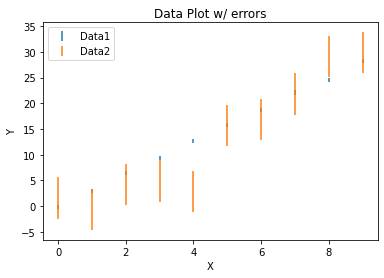

In [8]:
#This is my data input for the .txt files, may need to adjust the filepath
Data1=pd.read_csv('HW4_Data/data1.txt', names=['x', 'y', 'yerr'], delimiter=' ')
Data2=pd.read_csv('HW4_Data/data2.txt', names=['x', 'y', 'yerr'], delimiter=' ')

plt.errorbar(Data1['x'], Data1['y'], yerr=Data1['yerr'], label='Data1', linestyle='')
plt.errorbar(Data2['x'], Data2['y'], yerr=Data2['yerr'], label='Data2', linestyle='')
plt.legend()
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Data Plot w/ errors')
plt.show()

3a.)
The analytical formula for the MPV and reliability of the slope estimator is as follows

$p(\hat m|x, b, \sigma) = p(x|m, b, sigma)p(m)$

I'll use a uniform prior for p(m). I know slope is a scale parameter not a location parameter but this shouldn't really affect the answer that much/at all. p(m)=$\frac{1}{m_{max}-m_{min}}$

p(x|m, b, sigma) = $\prod_{i=1}^N p(x_i|m, b, \sigma)$

Errors on values are Gaussian. The key is that our gaussian will be centered at y-mx

p(x|m, b, sigma) = $\prod_{i=1}^N \frac{1}{\sqrt{2\pi}\sigma}e^{\frac{(y_i-mx_i)^2}{2\sigma^2}}$

$p(\hat m|x, b, \sigma) = \frac{1}{m_{max}-m_{min}} \prod_{i=1}^N \frac{1}{\sqrt{2\pi}\sigma}e^{\frac{(y_i-mx_i)^2}{2\sigma^2}}$

To start finding the MPV, we take the log of both sides to make this simpler to work with

$ln(p(\hat m|x, b, \sigma)) = ln(\frac{1}{m_{max}-m_{min}} \prod_{i=1}^N \frac{1}{\sqrt{2\pi}\sigma}e^{\frac{(y_i-mx_i)^2}{2\sigma^2}})$

$L = constant - \sum_{i=1}^N \frac{(y_i-mx_i)^2}{2\sigma^2}$

We maximize m by taking the derivitive with respect to m, and find when the derivitive = 0

$\frac{dL}{dm} = \frac{d}{dm}(constant - \sum_{i=1}^N \frac{(y_i-mx_i)^2}{2\sigma^2})$

$0 = -\frac{1}{2\sigma^2} \sum_{i=1}^N \frac{d}{dm}(y_i-mx_i)^2)$

$0 = -\frac{1}{2\sigma^2} \sum_{i=1}^N -2x_i(y_i-mx_i)$

$0 = \frac{1}{\sigma^2} (\sum_{i=1}^N x_iy_i - m\sum_{i=1}^N x_i^2)$

Now we find the estimator $\hat m$

$\frac{\hat m}{\sigma^2}\sum_{i=1}^N x_i^2) = \frac{1}{\sigma^2} \sum_{i=1}^N x_iy_i$

$\hat m = \frac{\sum_{i=1}^N x_iy_i}{\sum_{i=1}^N x_i^2}$

This is the expression to find the best estimator for the slope of a set of linear data with 0 yintercept and constant gaussian error. We see $\sigma$ dependence drops out here for the estimator of the slope.

------------------------------------------------------------------------------------------------

For the reliability of the estimator we use $Var(\hat m) = -(\frac{d^2L}{dm^2}|_{m=\hat m})^{-1}$

$Var(\hat m) = -(\frac{d^2L}{dm^2}|_{m=\hat m})^{-1}$

$Var(\hat m) = -(\frac{d}{dm}\frac{1}{\sigma^2} (\sum_{i=1}^N x_iy_i - m\sum_{i=1}^N x_i^2)|_{m=\hat m})^{-1}$

$Var(\hat m) = -(\frac{1}{\sigma^2}(-\sum_{i=1}^N x_i^2)|_{m=\hat m}))^{-1}$

$Var(\hat m) = (\frac{\sum_{i=1}^N x_i^2)}{\sigma^2})^{-1}$

$Var(\hat m) = \frac{\sigma^2}{\sum_{i=1}^N x_i^2}$

Now we use $Var(x) = \sigma^2_x$

$\sigma^2_{\hat m} = \frac{\sigma^2}{\sum_{i=1}^N x_i^2}$

$\sigma_{\hat m} = \sqrt{(\frac{\sigma^2}{\sum_{i=1}^N x_i^2})}$

$\sigma_{\hat m} = \frac{\sigma}{\sqrt{\sum_{i=1}^N x_i^2}}$

In [9]:
#3b.)

#We now have formulas for the estimator and reliability of the slope of the line, given the data.
#Let's make some quick functions to do that math and see what we get

def Estimator(Data):
    Numerator=np.sum(Data['x']*Data['y'])
    Denominator = np.sum(Data['x']**2)
    return(Numerator/Denominator)
def EstimatorReliability(Data):
    Numerator=Data['yerr'][0] #I could probably rewrite this to use the sum over these but mmmmmm sounds like work
    Denominator = np.sqrt(np.sum(Data['x']**2))
    return(Numerator/Denominator)

#I'll print to 3 decimal places because that's what I did in HW 4
print(f"Data1 has a slope estimator of {Estimator(Data1):.3f} "
      f"and a reliability of {EstimatorReliability(Data1):.3f}")

print(f"Data2 has a slope estimator of {Estimator(Data2):.3f} "
      f"and a reliability of {EstimatorReliability(Data2):.3f}")

#OK so Data1 slope estimator is matched up exactly with HW4 results, though Data2 is not. But within reliability
#The reliabilities are not the same as the 68% mark but idk I think I did that wrong on HW 4 anyway

Data1 has a slope estimator of 3.128 and a reliability of 0.024
Data2 has a slope estimator of 3.041 and a reliability of 0.237


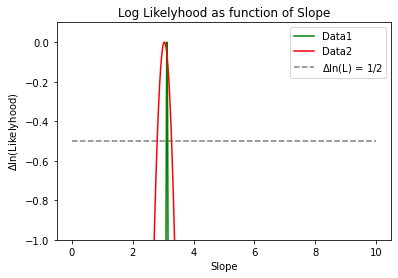

In [10]:
#3c.)
#for each dataset plot the log likelyhood function as a function of m, and use the points where ln(L)=1/2 to estimate sigma_m

#$ln(likelyhood) = ln(\prod_{i=1}^N \frac{1}{\sqrt{2\pi}\sigma}e^{\frac{(y_i-mx_i)^2}{2\sigma^2}})$
#$L = constant - \sum_{i=1}^N \frac{(y_i-mx_i)^2}{2\sigma^2}$
#Well this is in markdown but this is the function to use

def LogLikelyhood(Data, m): #I should have just left this in arrayable math whoops
    Constant = len(Data['x']) * np.log(1/(np.sqrt(2*np.pi) * Data['yerr'][0])) #again could take sigma to be more individual but this works for this case
    TheOtherPart = np.sum((Data['y']-m*Data['x'])**2 / (2*Data['yerr'][0]**2))
    return(Constant - TheOtherPart)

mtest=np.linspace(0, 10, 1001)
likelyhood1 = []
likelyhood2 = []
for i in range(len(mtest)):
    likelyhood1.append(LogLikelyhood(Data1, mtest[i]))
    likelyhood2.append(LogLikelyhood(Data2, mtest[i]))
    
likelyhood1 -= np.max(np.array(likelyhood1)) #Let's compute delta Likelyhood right here
likelyhood2 -= np.max(np.array(likelyhood2))
    
plt.plot(mtest, likelyhood1, label='Data1',color='green')
plt.plot(mtest, likelyhood2, label='Data2', color='red')
plt.title('Log Likelyhood as function of Slope')
plt.xlabel('Slope')
plt.ylabel(r'$\Delta$ln(Likelyhood)')
plt.ylim(-1, 0.1) #need these since everything is at max 0 and can be wayyyyy negative sometimes
plt.hlines(-1/2, 0, 10, linestyle = '--', color = 'gray', label = r'$\Delta$ln(L) = 1/2')
plt.legend()
plt.show()

In [11]:
#We need to find the crossing points for the deltaL = 1/2 point

Mask1 = likelyhood1 > -1/2
Mask2 = likelyhood2 > -1/2

print('The values of m which have logLikelyhood1 > -1/2 are', mtest[Mask1])
print('The values of m which have logLikelyhood2 > -1/2 are', mtest[Mask2])

#We can calculate sigma_m from the deltas, which is just max-min
print('sigma_m for Data1 is', (max(mtest[Mask1])-min(mtest[Mask1]))/2) #divide by 2 to get half width not full
print('sigma_m for Data2 is', (max(mtest[Mask2])-min(mtest[Mask2]))/2)

The values of m which have logLikelyhood1 > -1/2 are [3.11 3.12 3.13 3.14 3.15]
The values of m which have logLikelyhood2 > -1/2 are [2.81 2.82 2.83 2.84 2.85 2.86 2.87 2.88 2.89 2.9  2.91 2.92 2.93 2.94
 2.95 2.96 2.97 2.98 2.99 3.   3.01 3.02 3.03 3.04 3.05 3.06 3.07 3.08
 3.09 3.1  3.11 3.12 3.13 3.14 3.15 3.16 3.17 3.18 3.19 3.2  3.21 3.22
 3.23 3.24 3.25 3.26 3.27]
sigma_m for Data1 is 0.020000000000000018
sigma_m for Data2 is 0.22999999999999998


In [12]:
#3d.)
#Let's now do a 2d thingy, let the yintercept be a free parameter

def LogLikelyhoodNew(Data, m, b):
    Constant = len(Data['x']) * np.log(1/(np.sqrt(2*np.pi) * Data['yerr'][0])) #again could take sigma to be more individual but this works for this case
    TheOtherPart = np.sum((Data['y']-(m*Data['x']+b))**2 / (2*Data['yerr'][0]**2))
    return(Constant - TheOtherPart)

mtestdensity=1001
btestdensity=101
mtest=np.linspace(0, 10, mtestdensity)
btest=np.linspace(-5,5, btestdensity)

xx, yy = np.meshgrid(mtest, btest)
zz = LogLikelyhoodNew(Data1, xx, yy)
temp=[]
for i in range(len(mtest)):
    for j in range(len(btest)):
        temp.append(LogLikelyhoodNew(Data1, mtest[i], btest[j]))
temp=np.array(temp)
temp=temp.reshape(mtestdensity, btestdensity)
temp = temp - np.max(temp) #this gets us delta(ln(L))

temp2=[]
for i in range(len(mtest)):
    for j in range(len(btest)):
        temp2.append(LogLikelyhoodNew(Data2, mtest[i], btest[j]))
temp2=np.array(temp2)
temp2=temp2.reshape(mtestdensity, btestdensity)
temp2 = temp2 - np.max(temp2) #this gets us delta(ln(L))

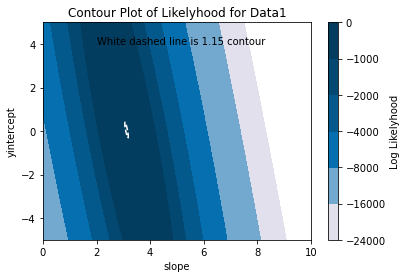

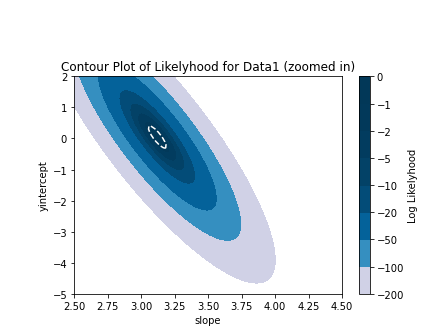

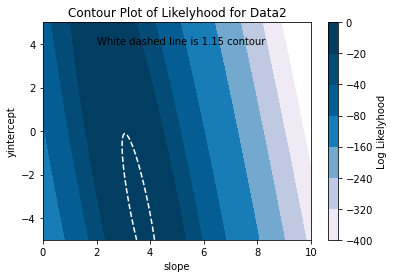

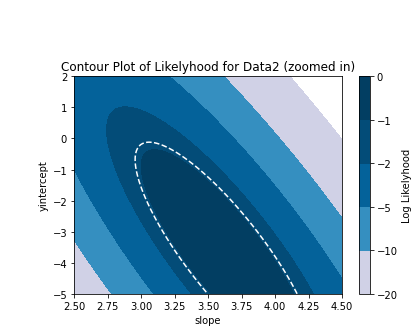

In [13]:
#Test making the plot without rerunning data generation
#I really should have made it run on a meshgrid whoops. Especially since I'm sorta figuring that out
#instead of fast vectorization expect the cell above to take a minute whoops

plt.contourf(mtest, btest, temp.T, cmap='PuBu', levels=np.flip(-np.array([0, 1000, 2000, 4000, 8000, 16000, 24000]))) #whyyyyy does this want transposed? Not sure at all
plt.colorbar(label='Log Likelyhood')
plt.contour(mtest, btest, temp.T, levels=[-1.15], colors='white')
plt.annotate('White dashed line is 1.15 contour', (2, 4))
plt.ylabel('yintercept')
plt.xlabel('slope')
plt.title('Contour Plot of Likelyhood for Data1')
plt.show()

plt.contourf(mtest, btest, temp.T, cmap='PuBu', levels=np.flip(-np.array([0, 1, 2, 5, 10, 20, 50, 100, 200]))) #whyyyyy does this want transposed? Not sure at all
plt.colorbar(label='Log Likelyhood')
plt.contour(mtest, btest, temp.T, levels=[-1.15], colors='white')
plt.annotate('White dashed line is 1.15 contour', (2, 4))
plt.ylabel('yintercept')
plt.xlabel('slope')
plt.title('Contour Plot of Likelyhood for Data1 (zoomed in)')
plt.xlim(2.5, 4.5)
plt.ylim(-5, 2)
plt.show()

plt.contourf(mtest, btest, temp2.T, cmap='PuBu', levels=np.flip(-np.array([0, 20, 40, 80, 160, 240, 320, 400]))) #whyyyyy does this want transposed? Not sure at all
plt.colorbar(label='Log Likelyhood')
plt.contour(mtest, btest, temp2.T, levels=[-1.15], colors='white')
plt.annotate('White dashed line is 1.15 contour', (2, 4))
plt.ylabel('yintercept')
plt.xlabel('slope')
plt.title('Contour Plot of Likelyhood for Data2')
plt.show()

plt.contourf(mtest, btest, temp2.T, cmap='PuBu', levels=np.flip(-np.array([0, 1, 2, 5, 10, 20]))) #whyyyyy does this want transposed? Not sure at all
plt.colorbar(label='Log Likelyhood')
plt.contour(mtest, btest, temp2.T, levels=[-1.15], colors='white')
plt.annotate('White dashed line is 1.15 contour', (2, 4))
plt.ylabel('yintercept')
plt.xlabel('slope')
plt.title('Contour Plot of Likelyhood for Data2 (zoomed in)')
plt.xlim(2.5, 4.5) #keeping this the same between datasets so you can really see the difference
plt.ylim(-5, 2)
plt.show()

#So some quick rationalization is that if the yint goes down, the slope has to go up to 'catch up' to the data again
#And I guess with the way the data is, it's much harder for it to have a positive yint and less slope
#Therefore for the Data2 plot, the 1.15 contour can extend to loweer yint and greater slope, but not vice versa

<ipython-input-20-dc15530e1e15>:15: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  resid = y[None,None,:] - (m[:,:,None]*x[None,None,:] + b[:,:,None])


Text(0, 0.5, 'y-intercept')

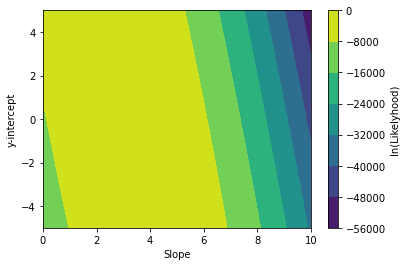

In [20]:
mtestdensity=1001
btestdensity=101
mtest=np.linspace(0, 10, mtestdensity)
btest=np.linspace(-5,5, btestdensity)
xx, yy = np.meshgrid(mtest, btest)

def LogLikelyhoodNewTest(Data, m, b):
    x = Data['x']
    y = Data['y']
    sigma = Data['yerr'][0] #This is conctant across all the
    Constant = len(x) * np.log(1/(np.sqrt(2*np.pi) * sigma))
    resid = y[None,None,:] - (m[:,:,None]*x[None,None,:] + b[:,:,None])
    chi_term = np.sum(resid**2 / (2*sigma**2), axis=2)
    return(Constant - chi_term)

zz = LogLikelyhoodNewTest(Data1, xx, yy)

plt.contourf(xx, yy, zz)
plt.colorbar(label='ln(Likelyhood)')
plt.xlabel('Slope')
plt.ylabel('y-intercept')



